In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'weight vs height')

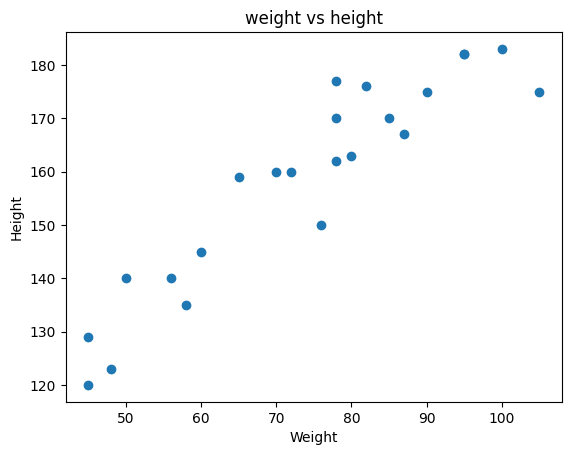

In [7]:
#### scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('weight vs height')

In [ ]:
df.corr()
##it shows the realationship between the weight and height is 0.95 which is very good for linear regression

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [10]:
import seaborn as sns

##### sns.pairplot is used to plot pairwise relationships in a dataset. It creates a grid of axes such that each variable in the data will be shared across the y-axes across a single row and the x-axes across a single column. This allows you to visualize the relationships between all pairs of variables in the dataset.

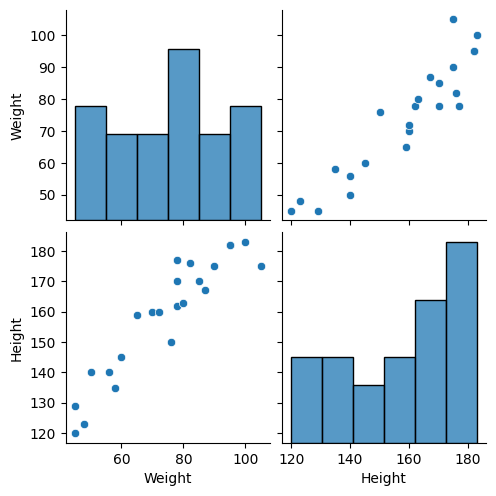

In [11]:
sns.pairplot(df)

In [18]:
#### Independent and Dependent features
# whenever you try to make independent feature make sure you yuo have dataframe and 2 dimensinal
X = df[["Weight"]]
X
np.array(X).shape

(23, 1)

In [ ]:
## for dependent feature one column is enough no need to make it 2 dimensional but why we made independent feature 2 dimensional because we have to make it dataframe and dataframe is 2 dimensional and also it need for ml model to train the data
Y = df["Height"]## this variable can be series in  or one dimensional array

In [20]:
Y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [21]:
### Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [22]:
X_train.shape

(17, 1)

#### Standardization means to make the data in the same scale because if we have different scale then it will affect the performance of the model and also it will affect the convergence of the model and also it will affect the accuracy of the model
from sklearn.preprocessing import StandardScaler   

such way we ahev formula 
z = Xi - mean(X) / std(X)
mew = 0 and std  = 1

In [24]:
from sklearn.preprocessing import StandardScaler


Q :what is Data leakage<br>
A : Data leakage is a situation in which information from outside the training dataset is used to create the model. This can lead to overfitting and poor generalization performance on new data. Data leakage can occur when features that are not available at the time of prediction are included in the training data, or when the target variable is included in the features. It is important to identify and prevent data leakage to ensure that the model is trained on relevant and unbiased data.

Q : Why we need to scale the data?<br>
A : Because in linear regression the cost function is based on the distance between the predicted value and the actual value and if the features are on different scales then the cost function will be dominated by the feature with the larger scale and it will not be able to learn the relationship between the features and the target variable properly.

Q: why we use fit_tranform in train data and only transform in test data
A : we use fit_transform in train data because we want to calculate the mean and standard deviation of the train data and then we use those mean and standard deviation to transform the train data and also we use those mean and standard deviation to transform the test data because we want to use the same mean and standard deviation for both train and test data so that we can compare the results of both train and test data on the same scale. if we use fit_transform on test data then it will calculate the mean and standard deviation of the test data which will be different from the mean and standard deviation of the train data and then we will not be able to compare the results of both train and test data on the same scale.

explain the aboeb fit_tranform and tranform with an example or analogy <br>
example: fit_transform is like learning how to drive a car, it learns the rules of the road and how to operate the car, while transform is like actually driving the car, it applies what it has learned to the new data.


In [27]:
Scaler = StandardScaler()
X_train =Scaler.fit_transform(X_train)

In [28]:
X_test = Scaler.transform(X_test)

In [30]:
## apply linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression(n_jobs=-1)
model.fit(X_train, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
model.coef_ ## this is the slope of the line


array([17.2982057])

In [34]:
model.intercept_ ## this is the intercept of the line

np.float64(156.47058823529412)

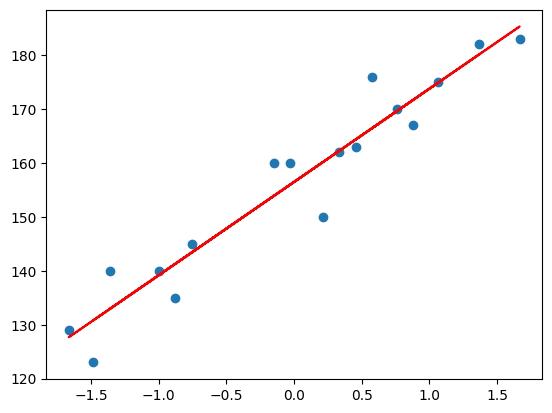

In [36]:
## plot Training data best fit line
plt.scatter(X_train, Y_train)
plt.plot(X_train,model.predict(X_train), color='red')

In [38]:
## Predction for the test data
y_pred = model.predict(X_test)

In [43]:
## performance of the model
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

print("R2 Score:",r2_score(Y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(Y_test,y_pred))
print("Mean Absolute Error:",mean_absolute_error(Y_test,y_pred))

R2 Score: 0.7360826717981276
Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501


R² Score = 0.736, indicating that the model explains approximately 73.6% of the variance in the target variable.

Mean Squared Error (MSE) = 114.84, which represents the average squared prediction error. Lower values indicate better performance.

Mean Absolute Error (MAE) = 9.67, meaning the model's predictions differ from the actual values by approximately 9.67 units on average.

MSE is higher than MAE because MSE squares the errors, giving larger penalties to bigger prediction mistakes.

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
print("Mean Absolute Percentage Error:",mean_absolute_percentage_error(Y_test,y_pred))


Mean Absolute Percentage Error: 0.059563628282977864


In [45]:
## OLS : Ordinary Least Square
import statsmodels.api as sms

ModuleNotFoundError: No module named 'statsmodels'

In [46]:
!pip install statsmodels 

In [52]:
# OLS : Ordinary Least Square
import statsmodels.api as sms
mod = sms.OLS(Y_train,X_train).fit()
pred = model.predict(X_train)

In [54]:
print(pred)

[-15.16409156  28.84875956   5.79440897 -25.64334183  23.60913442
 -28.78711691 -13.06824151  -2.58899124   3.69855892 -23.54749178
 -17.25994162  -0.49314119  18.36950929   9.98610908  13.12988416
  15.22573421   7.89025902]


In [55]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 31 May 2026   Prob (F-statistic):                       0.664
Time:                        13:22:12   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [57]:
## Prediction for the new data 
model.predict(Scaler.transform([[72]]))

c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([-0.49314119])